# **Decision Tree and Random Forest Classifier Models**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
data = pd.read_csv("/content/drive/MyDrive/2024_2학기/ESAA OB/필사 과제/drug200.csv")
data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [4]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [5]:
data.corr(numeric_only=True)

,Age,Na_to_K
Age,1.000000,-0.063119
Na_to_K,-0.063119,1.000000


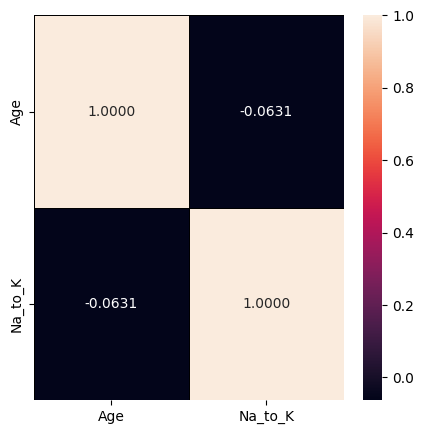

In [6]:
f, ax = plt.subplots(figsize = (5,5))
sns.heatmap(data.corr(numeric_only=True), annot = True, linewidths=0.5, linecolor = "black", fmt = ".4f", ax = ax)
plt.show()

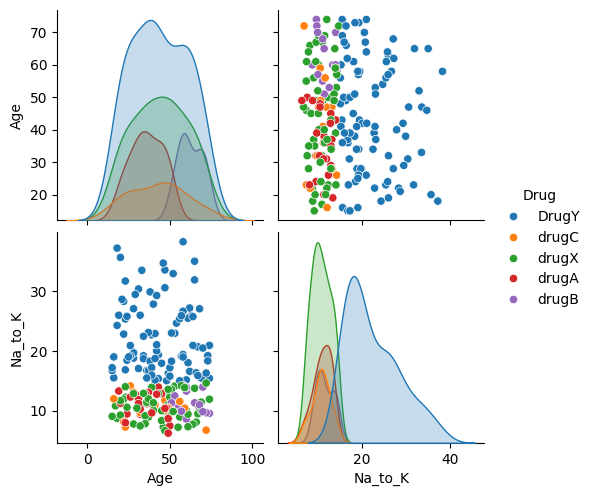

In [7]:
sns.pairplot(data, hue="Drug")

In [8]:
data.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [9]:
data["Age"].value_counts(dropna=False)

,count
Age,
47,8
23,7
28,7
49,7
39,6
32,6
50,5
37,5
58,5


In [10]:
data["Sex"].value_counts()

,count
Sex,
M,104
F,96


In [11]:
data["BP"].value_counts()

,count
BP,
HIGH,77
LOW,64
NORMAL,59


In [12]:
data["Cholesterol"].value_counts()

,count
Cholesterol,
HIGH,103
NORMAL,97


In [13]:
data["Drug"].value_counts()

,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


## **Data Visualization**


In [14]:
dataAge = data["Age"].value_counts(dropna=False)
npar_dataAge = np.array(dataAge)
x = list(npar_dataAge)
y = data.Age.value_counts().index

DataAge = {"Age":y, "Number":x}
DataAge = pd.DataFrame(DataAge)

fig = px.bar(DataAge, x="Age", y="Number")
fig.show()

In [16]:
colors = ['gold','mediumturquoise']
fig = go.Figure(data = [go.Pie(labels=['M','F'], values=[104,96])])

fig.update_traces(hoverinfo = 'label + percent', textinfo = 'value',textfont_size = 20, marker=dict(colors = colors, line=dict(color='#000000', width=2)))
fig.show()

In [17]:
fig = px.bar(x=["HIGH","LOW","NORMAL"], y=[77,64,59])
fig.show()

In [18]:
fig = px.histogram(x=["HIGH","NORMAL"], y=[103,97])
fig.show()

In [19]:
fig = go.Figure(data=[go.Pie(labels=["DrugY","DrugX","DrugA","DrugC","DrugB"], values = [91,54,23,16,16])])
fig.update_traces(hoverinfo = 'label + percent', textinfo = 'value', textfont_size = 20, marker = dict(colors=px.colors.sequential.RdBu, line=dict(color='#000000', width=2)))
fig.show()

In [20]:
fig = px.scatter(data, x="Na_to_K", y = "Age", color="Drug", size='Age',hover_data=['Na_to_K'])
fig.show()

##**Classifications Models**

### Data Preparing

In [21]:
dataclass = pd.read_csv("/content/drive/MyDrive/2024_2학기/ESAA OB/필사 과제/drug200.csv")

In [22]:
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [23]:
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [24]:
dataclass.Sex = [1 if i=="F" else 0 for i in dataclass.Sex]

In [25]:
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,HIGH,HIGH,25.355,DrugY
1,47,0,LOW,HIGH,13.093,drugC
2,47,0,LOW,HIGH,10.114,drugC
3,28,1,NORMAL,HIGH,7.798,drugX
4,61,1,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,LOW,HIGH,11.567,drugC
196,16,0,LOW,HIGH,12.006,drugC
197,52,0,NORMAL,HIGH,9.894,drugX
198,23,0,NORMAL,NORMAL,14.020,drugX


In [26]:
import warnings
warnings.filterwarnings('ignore')

for i in range(0, len(dataclass.BP)):
    if dataclass.BP[i] == "LOW":
        dataclass.BP[i] =2
    elif dataclass.BP[i] == "NORMAL":
        dataclass.BP[i]=1
    else:
        dataclass.BP[i]=0

In [27]:
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,HIGH,25.355,DrugY
1,47,0,2,HIGH,13.093,drugC
2,47,0,2,HIGH,10.114,drugC
3,28,1,1,HIGH,7.798,drugX
4,61,1,2,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,2,HIGH,11.567,drugC
196,16,0,2,HIGH,12.006,drugC
197,52,0,1,HIGH,9.894,drugX
198,23,0,1,NORMAL,14.020,drugX


In [28]:
dataclass.Cholesterol = [1 if i == "HIGH" else 0 for i in dataclass.Cholesterol]

In [29]:
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,1,25.355,DrugY
1,47,0,2,1,13.093,drugC
2,47,0,2,1,10.114,drugC
3,28,1,1,1,7.798,drugX
4,61,1,2,1,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,2,1,11.567,drugC
196,16,0,2,1,12.006,drugC
197,52,0,1,1,9.894,drugX
198,23,0,1,0,14.020,drugX


In [30]:
import warnings
warnings.filterwarnings('ignore')

for i in range(0,len(dataclass)):
    if dataclass.Drug[i] == "DurgY":
        dataclass.Drug[i]=4
    elif dataclass.Drug[i] == "drugX":
        dataclass.Drug[i] = 3
    elif dataclass.Drug[i] == "drugA":
        dataclass.Drug[i] = 2
    elif dataclass.Drug[i] == "drugC":
        dataclass.Drug[i] = 1
    else:
        dataclass.Drug[i] = 0

In [31]:
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,1,25.355,0
1,47,0,2,1,13.093,1
2,47,0,2,1,10.114,1
3,28,1,1,1,7.798,3
4,61,1,2,1,18.043,0
...,...,...,...,...,...,...
195,56,1,2,1,11.567,1
196,16,0,2,1,12.006,1
197,52,0,1,1,9.894,3
198,23,0,1,0,14.020,3


In [32]:
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.5+ KB


In [33]:
data_types_dict = {'BP':int, "Drug":int}
dataclass = dataclass.astype(data_types_dict)
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


In [35]:
x_data = dataclass.drop(["Drug"], axis=1)
y_data = dataclass.Drug.values
x_data

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,1,0,1,25.355
1,47,0,2,1,13.093
2,47,0,2,1,10.114
3,28,1,1,1,7.798
4,61,1,2,1,18.043
...,...,...,...,...,...
195,56,1,2,1,11.567
196,16,0,2,1,12.006
197,52,0,1,1,9.894
198,23,0,1,0,14.020


In [36]:
y_data

array([0, 1, 1, 3, 0, 3, 0, 1, 0, 0, 1, 0, 0, 0, 3, 0, 3, 2, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 3, 0, 0, 3, 0, 3, 0, 3, 3, 2, 3, 3, 3, 0, 0, 0, 3,
       3, 3, 2, 1, 0, 0, 0, 3, 0, 0, 0, 1, 0, 0, 3, 0, 0, 2, 0, 3, 0, 0,
       2, 3, 0, 0, 0, 0, 3, 0, 0, 0, 2, 0, 2, 3, 0, 3, 1, 2, 1, 0, 3, 0,
       0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 2, 2, 1, 3, 0, 3, 3, 0, 0, 0,
       2, 3, 3, 3, 3, 0, 3, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 3, 0, 0,
       3, 0, 0, 3, 0, 2, 0, 3, 2, 0, 0, 0, 2, 3, 3, 2, 3, 1, 2, 0, 3, 3,
       0, 1, 2, 0, 1, 3, 3, 0, 3, 0, 0, 0, 0, 3, 0, 2, 3, 3, 0, 0, 2, 0,
       2, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 1, 1, 3,
       3, 3])

In [37]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=1)

### Decision Tree Classifier

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

dtc = DecisionTreeClassifier()

dtc.fit(x_train, y_train)
predict = dtc.predict(x_test)
print('The accuracy of the Decision Tree is', metrics.accuracy_score(predict, y_test))

The accuracy of the Decision Tree is 0.9666666666666667


In [40]:
DTC_gini = DecisionTreeClassifier(criterion='gini', max_depth =3, random_state=0)
DTC_gini.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [41]:
y_pred_gini = DTC_gini.predict(x_test)

In [42]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion gini index:{0:0.4f}'.format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index:0.9000


In [43]:
y_pred_train_gini = DTC_gini.predict(x_train)
y_pred_train_gini

array([3, 3, 2, 0, 2, 3, 3, 3, 0, 2, 0, 3, 0, 3, 0, 3, 0, 3, 0, 0, 0, 0,
       3, 0, 2, 0, 3, 3, 2, 3, 0, 2, 0, 0, 3, 3, 3, 3, 3, 0, 0, 0, 0, 3,
       3, 0, 0, 2, 0, 3, 0, 3, 0, 0, 3, 3, 0, 0, 2, 0, 0, 0, 2, 3, 0, 0,
       0, 3, 0, 3, 3, 2, 3, 2, 0, 0, 0, 0, 3, 0, 0, 3, 3, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 3, 0, 3, 2, 0, 3, 0, 0, 3, 0, 0, 0, 0, 0, 0, 3, 0,
       0, 2, 3, 3, 3, 0, 3, 0, 0, 0, 0, 0, 2, 3, 3, 2, 0, 0, 0, 0, 0, 3,
       2, 0, 3, 0, 2, 3, 2, 3])

In [44]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_gini)))

Training-set accuracy score: 0.9143


In [45]:
print('Training set score: {:.4f}'.format(DTC_gini.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(DTC_gini.score(x_test, y_test)))

Training set score: 0.9143
Test set score: 0.9000


In [46]:
DTC_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
DTC_en.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [47]:
y_pred_en = DTC_en.predict(x_test)

In [48]:
print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy: 0.9000


In [49]:
y_pred_train_en = DTC_en.predict(x_train)
y_pred_train_en

array([3, 3, 2, 0, 2, 3, 3, 3, 0, 2, 0, 3, 0, 3, 0, 3, 0, 3, 0, 0, 0, 0,
       3, 0, 2, 0, 3, 3, 2, 3, 0, 2, 0, 0, 3, 3, 3, 3, 3, 0, 0, 0, 0, 3,
       3, 0, 0, 2, 0, 3, 0, 3, 0, 0, 3, 3, 0, 0, 2, 0, 0, 0, 2, 3, 0, 0,
       0, 3, 0, 3, 3, 2, 3, 2, 0, 0, 0, 0, 3, 0, 0, 3, 3, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 3, 0, 3, 2, 0, 3, 0, 0, 3, 0, 0, 0, 0, 0, 0, 3, 0,
       0, 2, 3, 3, 3, 0, 3, 0, 0, 0, 0, 0, 2, 3, 3, 2, 0, 0, 0, 0, 0, 3,
       2, 0, 3, 0, 2, 3, 2, 3])

In [50]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 0.9143


In [51]:
print('Training set score: {:.4f}'.format(DTC_en.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(DTC_en.score(x_test, y_test)))

Training set score: 0.9143
Test set score: 0.9000


### Random Forest Classifier

In [53]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=0)
rfc.fit(x_train,y_train)
predict = rfc.predict(x_test)
print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 0.95


In [54]:
from sklearn.ensemble import RandomForestClassifier

rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)
rfc_100.fit(x_train, y_train)
predict = rfc_100.predict(x_test)
print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 0.95


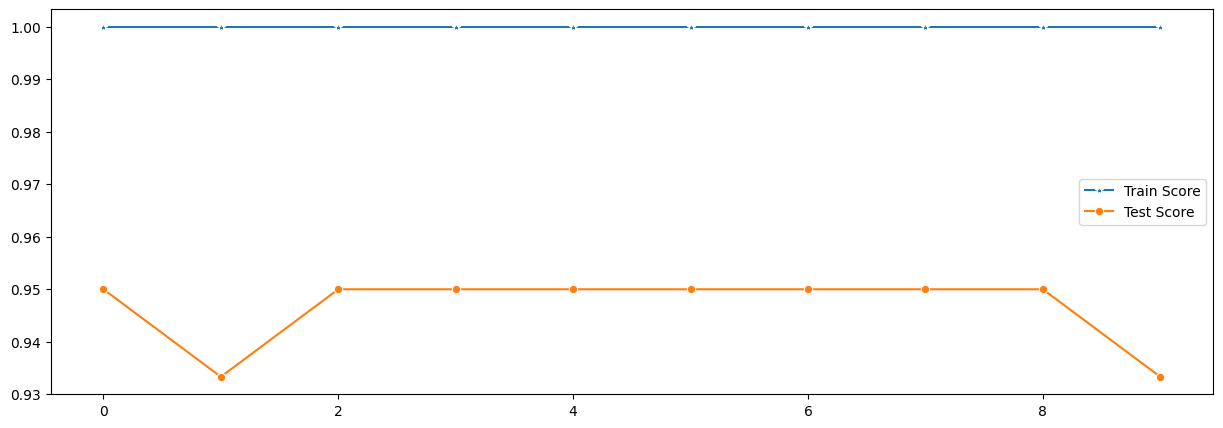

In [55]:
test_score_list = []
train_score_list = []

for i in range(0,10):
    rfc2 = RandomForestClassifier(random_state=i)
    rfc2.fit(x_train, y_train)
    test_score_list.append(rfc2.score(x_test, y_test))
    train_score_list.append(rfc2.score(x_train, y_train))

plt.figure(figsize=(15,5))
p = sns.lineplot(x=range(0, 10), y=train_score_list, marker='*', label='Train Score')
p = sns.lineplot(x=range(0, 10), y=test_score_list, marker='o', label='Test Score')

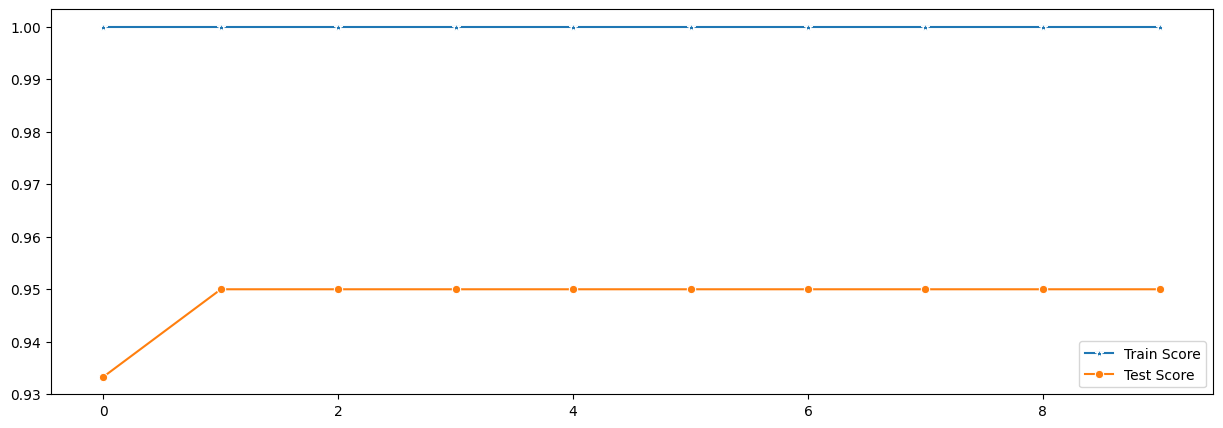

In [57]:
test_score_list = []
train_score_list = []

list_n_estimators = [10,20,30,40,50,60,70,80,90,100]


for i in range(0,len(list_n_estimators)):
    rfc3 = RandomForestClassifier(n_estimators=list_n_estimators[i], random_state=5)
    rfc3.fit(x_train, y_train)
    test_score_list.append(rfc3.score(x_test, y_test))
    train_score_list.append(rfc3.score(x_train, y_train))

plt.figure(figsize=(15,5))
p=sns.lineplot(x=range(0,len(list_n_estimators)),y=train_score_list,marker='*',label='Train Score')
p=sns.lineplot(x=range(0,len(list_n_estimators)),y=test_score_list,marker='o',label='Test Score')

In [58]:
last_rfc = RandomForestClassifier(n_estimators=100, random_state=5)
last_rfc.fit(x_train, y_train)
predict = last_rfc.predict(x_test)
print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 0.95


In [59]:
y_pred_en = last_rfc.predict(x_test)

In [60]:
print('Model accuracy score with best parameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with best parameters: 0.9500


In [61]:
y_pred_train_en = last_rfc.predict(x_train)

y_pred_train_en

array([3, 3, 2, 0, 2, 3, 3, 3, 0, 2, 0, 1, 0, 1, 0, 3, 0, 3, 0, 0, 0, 0,
       3, 0, 2, 0, 1, 3, 2, 3, 0, 2, 0, 0, 3, 3, 1, 3, 3, 0, 0, 0, 0, 3,
       1, 0, 0, 2, 0, 3, 0, 1, 0, 0, 1, 3, 0, 0, 2, 0, 0, 0, 2, 3, 0, 0,
       0, 3, 0, 1, 3, 2, 3, 2, 0, 0, 0, 0, 3, 0, 0, 3, 3, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 3, 0, 3, 2, 0, 1, 0, 0, 3, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 2, 3, 1, 1, 0, 3, 0, 0, 0, 0, 0, 2, 3, 3, 2, 0, 0, 0, 0, 0, 3,
       2, 0, 3, 0, 2, 3, 2, 3])

In [62]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 1.0000


In [63]:
print('Training set score: {:.4f}'.format(last_rfc.score(x_train, y_train)))

Training set score: 1.0000


In [64]:
print('Test set score: {:.4f}'.format(last_rfc.score(x_test, y_test)))

Test set score: 0.9500


### Evaluation Classification Models

In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

cm_des = DecisionTreeClassifier()

# fit the model
cm_des.fit(x_train,y_train)

y_pred_cm = cm_des.predict(x_test)
y_true = y_test

cm_des1 = confusion_matrix( y_true, y_pred_cm)
cm_des1

array([[31,  0,  2,  0],
       [ 0,  4,  0,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  0, 19]])

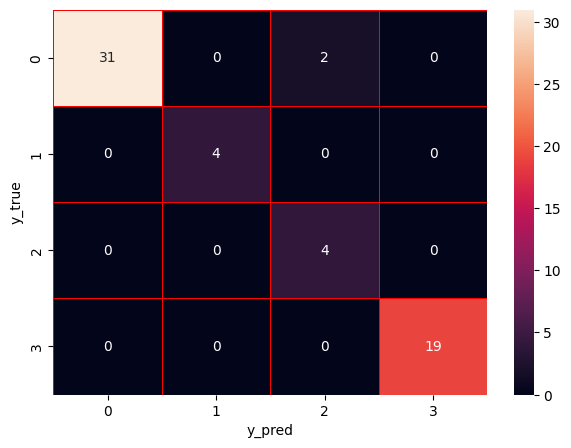

In [66]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des1, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [67]:
cm_des_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

# fit the model
cm_des_gini.fit(x_train,y_train)

y_pred_cm = cm_des_gini.predict(x_test)
y_true = y_test

cm_des2 = confusion_matrix( y_true, y_pred_cm)
cm_des2

array([[31,  0,  2,  0],
       [ 0,  0,  0,  4],
       [ 0,  0,  4,  0],
       [ 0,  0,  0, 19]])

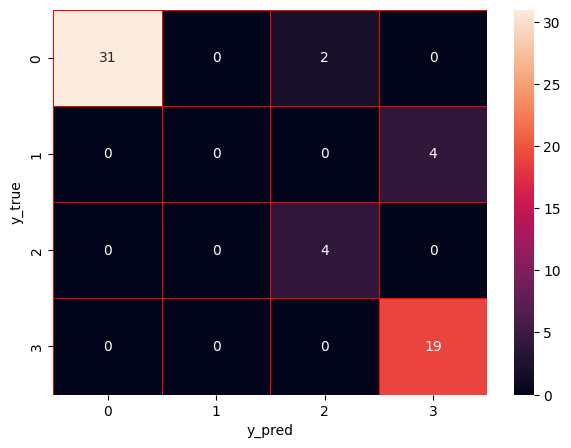

In [68]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des2, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [69]:
cm_last_rfc = RandomForestClassifier(n_estimators=100, random_state=5)

# Fit The Model
cm_last_rfc.fit(x_train, y_train)

y_pred_cm = cm_last_rfc.predict(x_test)
y_true = y_test

cm_rfc = confusion_matrix(y_true, y_pred_cm)
cm_rfc

array([[31,  0,  2,  0],
       [ 0,  3,  0,  1],
       [ 0,  0,  4,  0],
       [ 0,  0,  0, 19]])

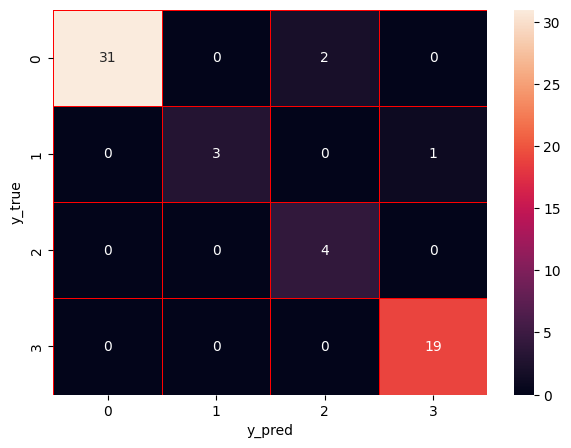

In [70]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_rfc, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()